In [5]:
# IMPORTANT FOR QUIZ 2!!!!!!!!

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from PIL import Image

folder_training_0 = "./MNIST/training/0/"
folder_training_1 = "./MNIST/training/1/"
folder_testing_0 = "./MNIST/testing/0/"
folder_testing_1 = "./MNIST/testing/1/"

def get_data(folder: str, im_width, label, n_samples):
    file_names = os.listdir(folder)
    x = np.empty((n_samples, im_width**2))
    y = np.empty((n_samples, 1))

    for i in range(n_samples):
        path = folder + file_names[i]
        im = Image.open(path).convert("L")  # convert to greyscale
        im = im.resize((im_width, im_width))
        im_array = np.asarray(im)
        x[i:] = im_array.reshape(1, -1)
        y[i, 0] = label
    return x, y

(200, 784) (200, 1)


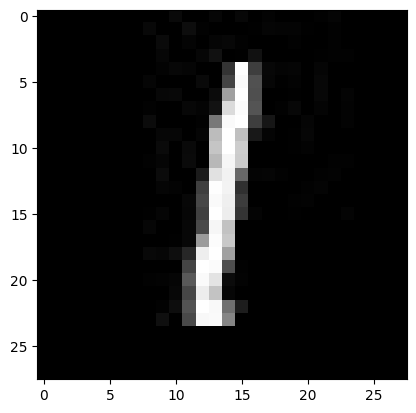

In [9]:
im_width = 28
n_samples = 100

x_0, y_0 = get_data(folder_training_0, im_width, 0, n_samples)
# print(x_0.shape, y_0.shape)
x_1, y_1 = get_data(folder_training_1, im_width, 1, n_samples)
x = np.vstack((x_0, x_1))
y = np.vstack((y_0, y_1))
print(x.shape, y.shape)

plt.imshow(x_1[0,:].reshape(im_width, im_width), cmap = "gray")

c:\Users\jason\Code\Python\engr418\.venv\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


(1, 784)
[[100   0]
 [  0 100]]
1.0


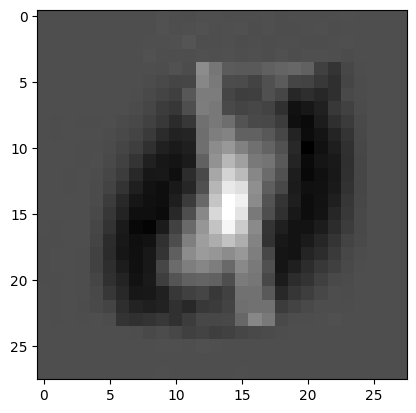

In [18]:
model = LogisticRegression(penalty = "l2", C = 0.1)
model.fit(x, y)

print(model.coef_.shape)
plt.imshow(model.coef_[0,:].reshape(im_width, im_width), cmap = "gray")

x_0_t, y_0_t = get_data(folder_testing_0, im_width, 0, n_samples)
# print(x_0.shape, y_0.shape)
x_1_t, y_1_t = get_data(folder_testing_1, im_width, 1, n_samples)
x_t = np.vstack((x_0_t, x_1_t))
y_t = np.vstack((y_0_t, y_1_t))

y_pred = model.predict(x_t)
print(confusion_matrix(y_t, y_pred))
print(accuracy_score(y_t, y_pred))